In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
df = pd.read_csv('C:/Users/shravan kumar/OneDrive/Desktop/github/credit-card-fraud-detection/data/creditcard.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Shape: (284807, 31)
Rows: 284,807
Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
df.describe().round(2)

=== DATA TYPES ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== MISSING VALUES ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


=== CLASS DISTRIBUTION ===
Legitimate transactions: 284,315 (99.83%)
Fraudulent transactions:  492 (0.17%)

Imbalance ratio: 577:1


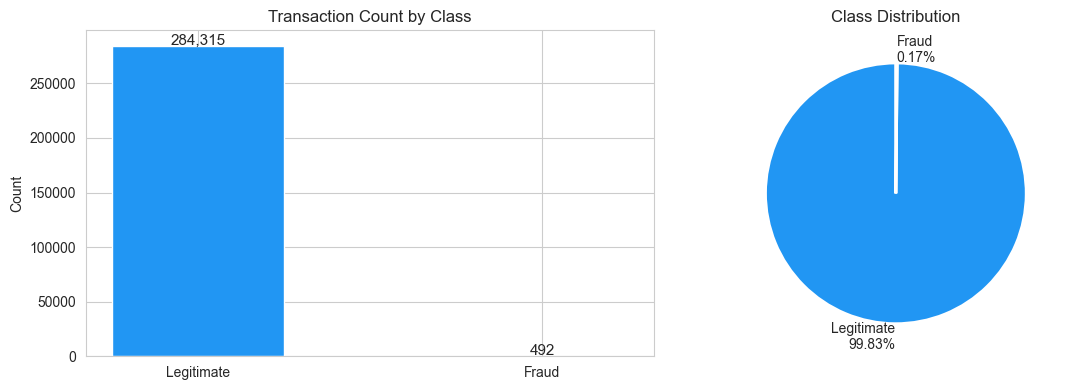

Chart saved to data/


In [5]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate transactions: {fraud_count[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent transactions:  {fraud_count[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"\nImbalance ratio: {fraud_count[0]//fraud_count[1]}:1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'],
            [fraud_count[0], fraud_count[1]],
            color=['#2196F3', '#F44336'],
            edgecolor='white', width=0.5)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate([fraud_count[0], fraud_count[1]]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie([fraud_count[0], fraud_count[1]],
            labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
            colors=['#2196F3', '#F44336'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('../data/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/")

C:\Users\shravan kumar\AppData\Local\Temp\ipykernel_22644\1322979802.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([legit, fraud],


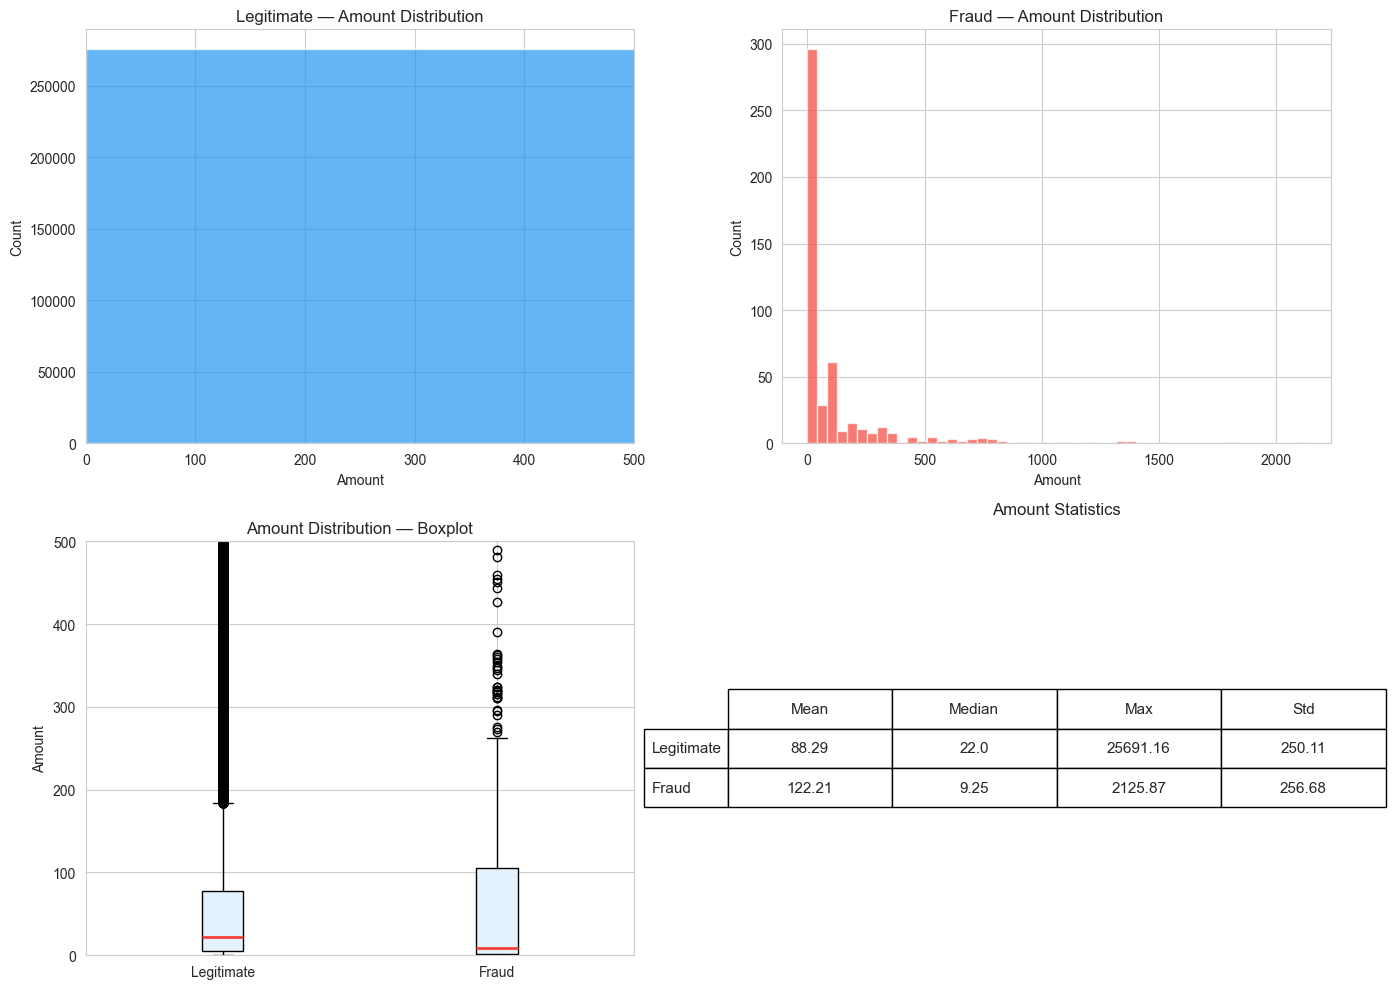

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

# Distribution of Amount for legit
axes[0,0].hist(legit, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0,0].set_title('Legitimate — Amount Distribution')
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xlim(0, 500)

# Distribution of Amount for fraud
axes[0,1].hist(fraud, bins=50, color='#F44336', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Fraud — Amount Distribution')
axes[0,1].set_xlabel('Amount')
axes[0,1].set_ylabel('Count')

# Boxplot comparison
axes[1,0].boxplot([legit, fraud],
                   labels=['Legitimate', 'Fraud'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#E3F2FD'),
                   medianprops=dict(color='#F44336', linewidth=2))
axes[1,0].set_title('Amount Distribution — Boxplot')
axes[1,0].set_ylabel('Amount')
axes[1,0].set_ylim(0, 500)

# Stats table
stats = df.groupby('Class')['Amount'].agg(['mean', 'median', 'max', 'std']).round(2)
stats.index = ['Legitimate', 'Fraud']
axes[1,1].axis('off')
table = axes[1,1].table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=['Mean', 'Median', 'Max', 'Std'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1,1].set_title('Amount Statistics', pad=20)

plt.tight_layout()
plt.savefig('../data/02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

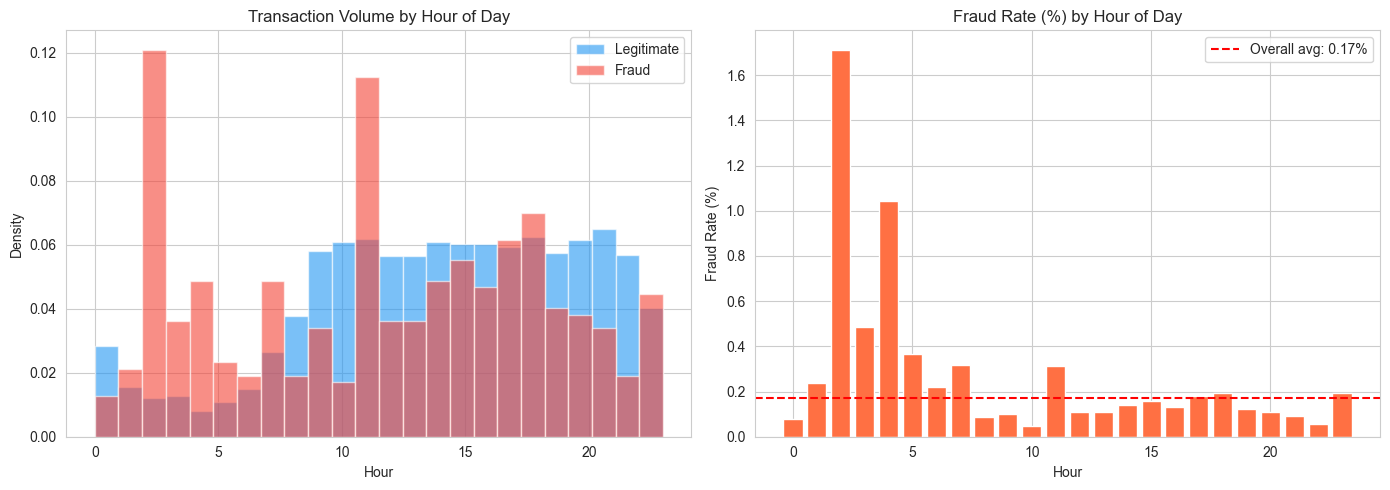


Highest fraud rate hour: 2.0:00
Lowest fraud rate hour:  10.0:00


In [7]:
df['Hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions per hour
legit_hours = df[df['Class'] == 0]['Hour']
fraud_hours = df[df['Class'] == 1]['Hour']

axes[0].hist(legit_hours, bins=24, color='#2196F3',
             alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud_hours, bins=24, color='#F44336',
             alpha=0.6, label='Fraud', density=True)
axes[0].set_title('Transaction Volume by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud rate per hour
hourly = df.groupby('Hour')['Class'].agg(['sum', 'count'])
hourly['fraud_rate'] = (hourly['sum'] / hourly['count']) * 100

axes[1].bar(hourly.index, hourly['fraud_rate'],
            color='#FF7043', edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=df['Class'].mean()*100,
                color='red', linestyle='--',
                label=f'Overall avg: {df["Class"].mean()*100:.2f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/03_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHighest fraud rate hour: {hourly['fraud_rate'].idxmax()}:00")
print(f"Lowest fraud rate hour:  {hourly['fraud_rate'].idxmin()}:00")

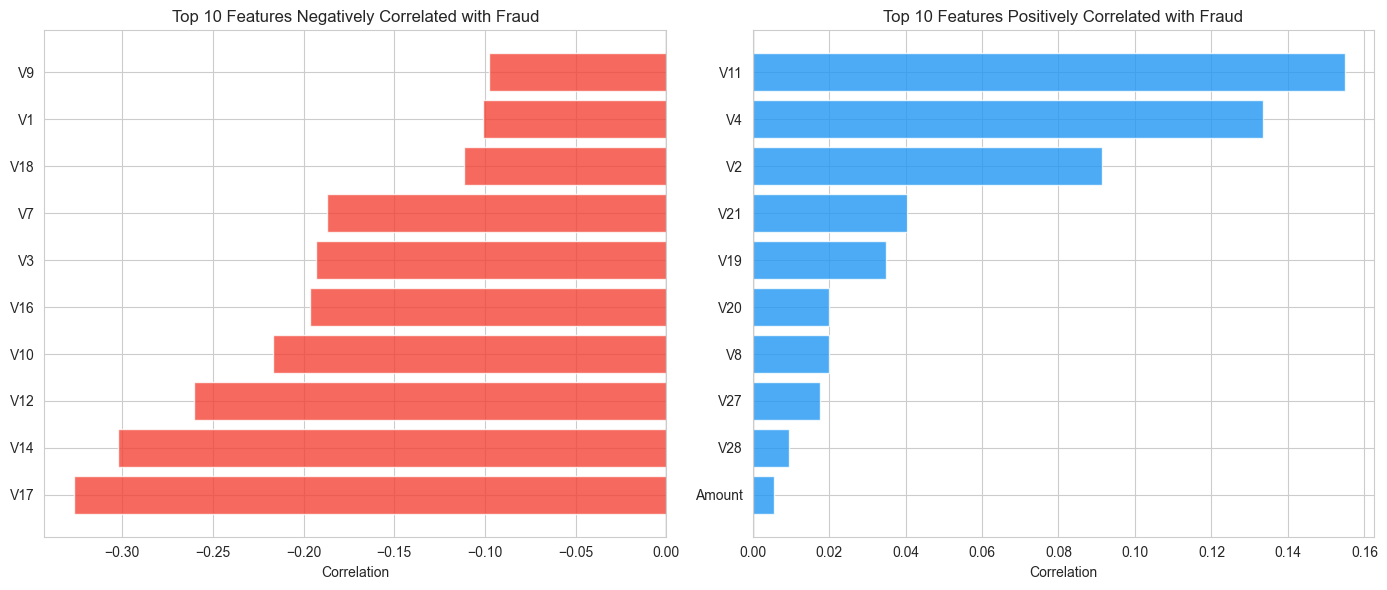


Top 5 most important features for detecting fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [8]:
# Correlation of each feature with Class
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 negative correlations (these features DECREASE with fraud)
top_neg = correlations.head(10)
axes[0].barh(top_neg.index, top_neg.values, color='#F44336', alpha=0.8)
axes[0].set_title('Top 10 Features Negatively Correlated with Fraud')
axes[0].set_xlabel('Correlation')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Top 10 positive correlations (these features INCREASE with fraud)
top_pos = correlations.tail(10)
axes[1].barh(top_pos.index, top_pos.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Top 10 Features Positively Correlated with Fraud')
axes[1].set_xlabel('Correlation')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../data/04_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features for detecting fraud:")
print(correlations.abs().sort_values(ascending=False).head(5))

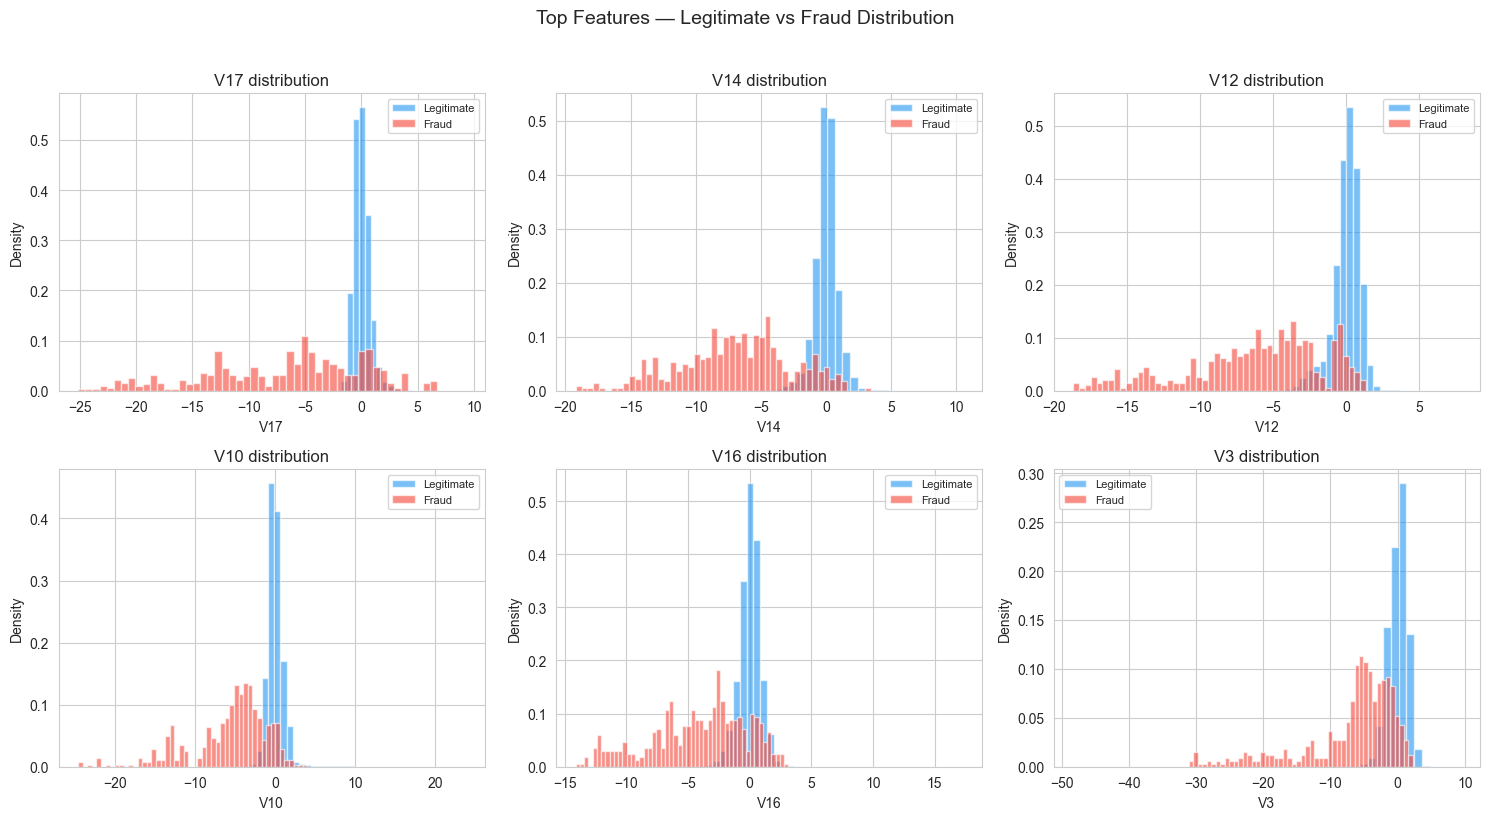

In [9]:
# Pick top 6 most correlated features
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    legit_vals = df[df['Class'] == 0][feature]
    fraud_vals = df[df['Class'] == 1][feature]

    axes[i].hist(legit_vals, bins=50, alpha=0.6,
                 color='#2196F3', label='Legitimate',
                 density=True)
    axes[i].hist(fraud_vals, bins=50, alpha=0.6,
                 color='#F44336', label='Fraud',
                 density=True)
    axes[i].set_title(f'{feature} distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Top Features — Legitimate vs Fraud Distribution',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/05_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

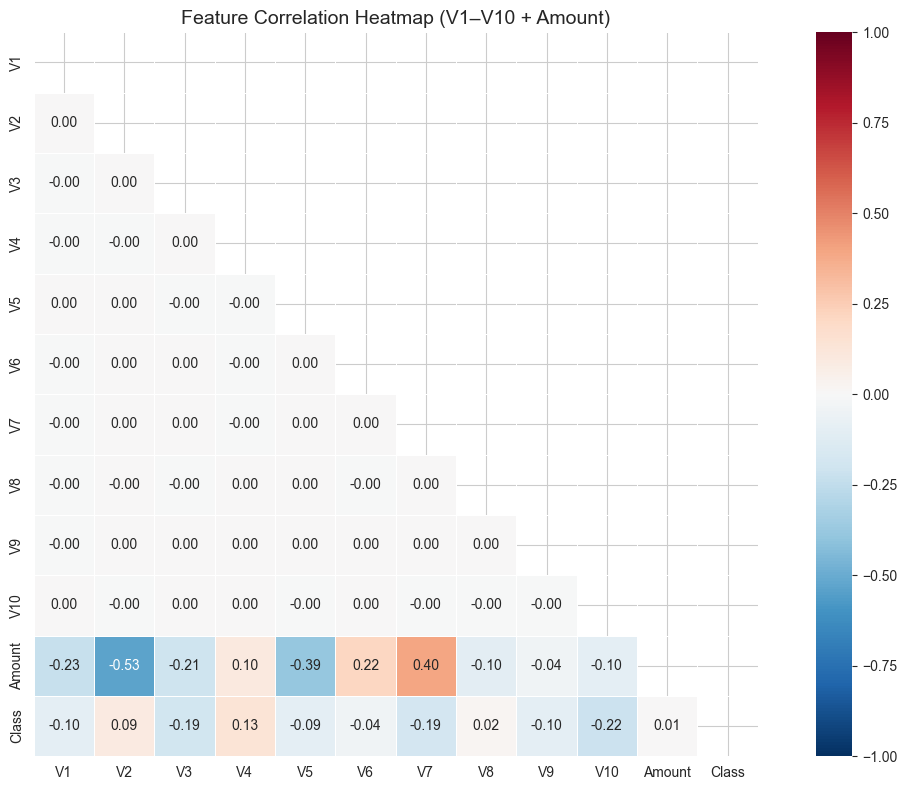

In [10]:
# Select V1-V10 for readability
v_features = [f'V{i}' for i in range(1, 11)] + ['Amount', 'Class']

plt.figure(figsize=(12, 8))
corr_matrix = df[v_features].corr()

mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap (V1–V10 + Amount)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/06_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 55)
print("         EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

print(f"""
DATASET
  Total transactions : {len(df):,}
  Features           : {df.shape[1] - 1} (Time, V1-V28, Amount)
  Missing values     : {df.isnull().sum().sum()}

CLASS IMBALANCE
  Legitimate         : {fraud_count[0]:,} ({fraud_pct[0]:.2f}%)
  Fraudulent         : {fraud_count[1]:,} ({fraud_pct[1]:.2f}%)
  Imbalance ratio    : {fraud_count[0]//fraud_count[1]}:1
  → Must use SMOTE or class_weight to handle this

AMOUNT INSIGHTS
  Avg legitimate     : ${df[df['Class']==0]['Amount'].mean():.2f}
  Avg fraudulent     : ${df[df['Class']==1]['Amount'].mean():.2f}
  Max fraud amount   : ${df[df['Class']==1]['Amount'].max():.2f}

MOST IMPORTANT FEATURES
  {', '.join(correlations.abs().sort_values(ascending=False).head(5).index.tolist())}

NEXT STEP
  → Open 02_preprocessing.ipynb
""")
print("=" * 55)

         EDA SUMMARY — KEY FINDINGS

DATASET
  Total transactions : 284,807
  Features           : 31 (Time, V1-V28, Amount)
  Missing values     : 0

CLASS IMBALANCE
  Legitimate         : 284,315 (99.83%)
  Fraudulent         : 492 (0.17%)
  Imbalance ratio    : 577:1
  → Must use SMOTE or class_weight to handle this

AMOUNT INSIGHTS
  Avg legitimate     : $88.29
  Avg fraudulent     : $122.21
  Max fraud amount   : $2125.87

MOST IMPORTANT FEATURES
  V17, V14, V12, V10, V16

NEXT STEP
  → Open 02_preprocessing.ipynb

